# CFE-PPAR — How the Video Encryption Works

This notebook shows, picture by picture, how CFE-PPAR scrambles a video frame so
its content is hidden. It's the "lock the video" half of the method — the
matching "unlock and still recognize it" half lives in `verify_consistency.py`.

Encryption happens at two levels, and we look at each in turn:

1. **Inside each block** — the frame is cut into small blocks, and five
   operations shuffle the pixels within every block (rotate, flip, invert
   colors, swap color channels, shuffle sub-blocks).
2. **Across the frame** — the blocks themselves are then shuffled to new
   positions.

We show each operation on its own, then stack them into full encryption, and
finally compare the two key schemes (V1 and V2).

*(Maps to the paper: level 1 = sub-block transforms A.3, level 2 = main-block
scrambling A.4, Sec. 3.2.)*

**Runs anywhere.** Needs only `numpy`, `matplotlib`, and `opencv-python` (to
load a frame) — no `torch`, no GPU. It finishes in about a second and the images
render inline, so it previews directly on GitHub.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from compression_friendly_encryption import (
    encrypt_frame,       # CFE on a single frame (A.1-A.4)
    SubBlockLevelCipher,
    derive_secret_keys,
    main_block_key,
    SUB_BLOCK_OPS,       # ('rot', 'flip', 'npt', 'cs', 'sbs')
    ALL_ENCRYPTION_OPS,  # SUB_BLOCK_OPS + ('mbs',)
)

VIDEO_PATH = "samples/plain_1.avi"
MAIN_BLOCK_SIZE = 16     # Hp = Wp, the VT patch size (paper A.1)
SUB_BLOCK_SIZE = 8       # Hs = Ws (paper A.2) -> 2x2 sub-blocks per main-block
FRAME_SIZE = 224         # model input resolution
SEED = 1                 # master secret; K_ST and K_MS are derived from it

# Human-readable names for each transform, for plot titles.
OP_LABELS = {
    "rot":  "rotation",
    "flip": "flipping",
    "npt":  "negative-positive\ninversion",
    "cs":   "RGB-channel\nshuffling",
    "sbs":  "sub-block\nscrambling",
    "mbs":  "main-block\nscrambling",
}


def show_panels(panels, title=None, width=2.2, height=2.6, caption_size=12,
                title_size=12, y=1.06, interpolation=None):
    """Draw a row of (caption, image) pairs.

    Every figure in this notebook is such a row, so all the matplotlib
    boilerplate lives here and the cells below stay about the encryption.
    Pass `interpolation="nearest"` when a tiny block is shown enlarged, so the
    individual pixels stay crisp; full frames are better left on matplotlib's
    default (antialiased), which is what they are being downscaled with."""
    fig, axes = plt.subplots(1, len(panels),
                             figsize=(width * len(panels), height))
    for ax, (caption, img) in zip(np.atleast_1d(axes), panels):
        ax.imshow(img, interpolation=interpolation)
        ax.set_title(caption, fontsize=caption_size)
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=title_size, y=y)
    plt.tight_layout()
    plt.show()

## The one function we need: `encrypt_frame`

Everything below is built on a single function imported above,
`encrypt_frame` — the module's own implementation of CFE on one frame
(`compression_friendly_encryption.py` uses the very same function to encrypt a
whole video, frame by frame). So nothing here is a re-implementation: what you
see is exactly what runs in the real pipeline.

Its `enabled` argument is the key trick for this walkthrough. It maps each
operation name (`rot`/`flip`/`npt`/`cs`/`sbs`/`mbs`) to `True` or `False`, which
lets us switch on **one operation at a time** and see what each does on its own.
Disabled operations still consume their share of the key stream, so the ones
left on behave exactly as they would under full encryption.

frame: (224, 224, 3) uint8
encrypt_frame OK — full-encryption frame differs from input


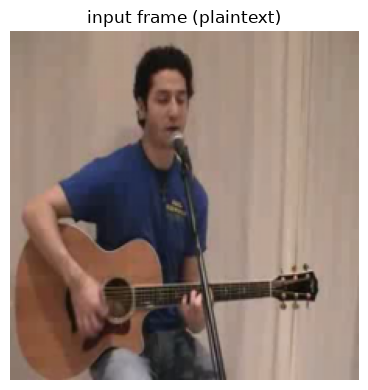

In [2]:
def synthetic_frame(size=FRAME_SIZE, block=MAIN_BLOCK_SIZE):
    """A fallback frame whose every main-block has a distinct flat color, so
    main-block scrambling is visually obvious even without a real video."""
    f = np.zeros((size, size, 3), dtype=np.uint8)
    for by in range(size // block):
        for bx in range(size // block):
            f[by*block:(by+1)*block, bx*block:(bx+1)*block] = [
                (by * 17) % 256, (bx * 17) % 256, ((by + bx) * 13) % 256]
    return f


def load_demo_frame(path=VIDEO_PATH, size=FRAME_SIZE):
    """Load the first frame of the sample clip as an (size, size, 3) uint8 RGB
    array. Falls back to a synthetic frame if the sample / opencv isn't
    available, so the notebook always runs end to end."""
    try:
        import video_io
        clip = video_io.read_clip(path, num_frames=1, size=size)  # (1,H,W,3)
        return clip[0]
    except Exception as e:
        print(f"[info] using a synthetic frame ({type(e).__name__}: {e})")
        return synthetic_frame(size)


frame = load_demo_frame()
print("frame:", frame.shape, frame.dtype)

# quick self-check: full encryption preserves shape/dtype but changes the pixels
_full = encrypt_frame(frame, SEED)
assert _full.shape == frame.shape and _full.dtype == frame.dtype
assert not np.array_equal(_full, frame), "encryption should change the frame"
print("encrypt_frame OK — full-encryption frame differs from input")

show_panels([("input frame (plaintext)", frame)], width=4, height=4)

## Step 1 — The five per-block operations, one at a time

The frame is divided into **main-blocks (MB)** of 16×16 pixels, and each MB is
divided again into **sub-blocks (SB)** of 8×8. Five operations then scramble the
pixels inside an MB. Below, each panel shows **one operation applied by itself**
to a single real MB, so you can see its individual effect.

These are the **real settings** the model actually uses (MB = 16, SB = 8). An MB
is tiny, so we zoom in — the pixels you see are exactly what the encryption
produces.

*(Paper: sub-block transforms A.3.)*

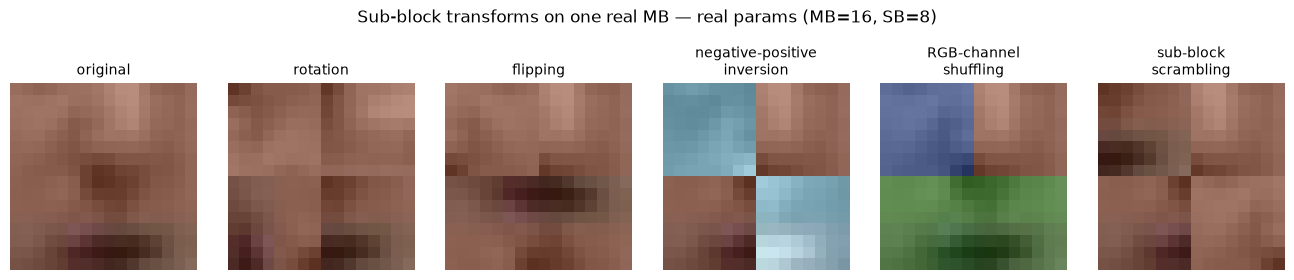

In [3]:
def encrypt_single_op(block, op, sub_block_size=SUB_BLOCK_SIZE, seed=SEED):
    """Encrypt one main-block with ONLY `op` active (A.3 sub-block ops).

    Goes one level below `encrypt_frame`, straight to the sub-block cipher,
    because here we want a single block rather than a whole frame."""
    cipher = SubBlockLevelCipher(sub_block_size=sub_block_size,
                                 enabled={o: (o == op) for o in SUB_BLOCK_OPS})
    K_ST, _ = derive_secret_keys(seed)
    return cipher.encrypt_main_block(block, main_block_key(K_ST, 0, "V1"))


# one real 16x16 main-block cut out of the frame (MB size = VT patch size)
BLOCK_ROW, BLOCK_COL = 3, 6
mb = MAIN_BLOCK_SIZE
demo_block = frame[BLOCK_ROW*mb:(BLOCK_ROW+1)*mb,
                   BLOCK_COL*mb:(BLOCK_COL+1)*mb].copy()

panels = [("original", demo_block)]
panels += [(OP_LABELS[op], encrypt_single_op(demo_block, op))
           for op in SUB_BLOCK_OPS]

show_panels(panels,
            "Sub-block transforms on one real MB — real params (MB=16, SB=8)",
            caption_size=10, interpolation="nearest")

## Step 1, again — but on a zoomed-in block, just to see it clearly

> ⚠️ **This panel is for intuition only — not the real sizes.** It shows a single
> **main-block (MB)** blown up to 112×112, split into four 56×56 **sub-blocks
> (SB)**. The real pipeline uses MB = 16 and SB = 8 (the previous step); this
> zoomed MB is only here so the operations are easy to see.

Each sub-block is **numbered**, and the number is painted into the block itself,
so it travels with the content. That makes every operation easy to follow:
- **rotation / flipping** — the digit turns or mirrors with its sub-block
- **negative-positive inversion** — colors flip to their opposite (like a photo
  negative); the digit stays put, telling you nothing *moved*
- **RGB-channel shuffling** — only the colors change, numbers don't move
- **sub-block scrambling** — whole numbered sub-blocks swap places, so you can
  read off exactly where each one went

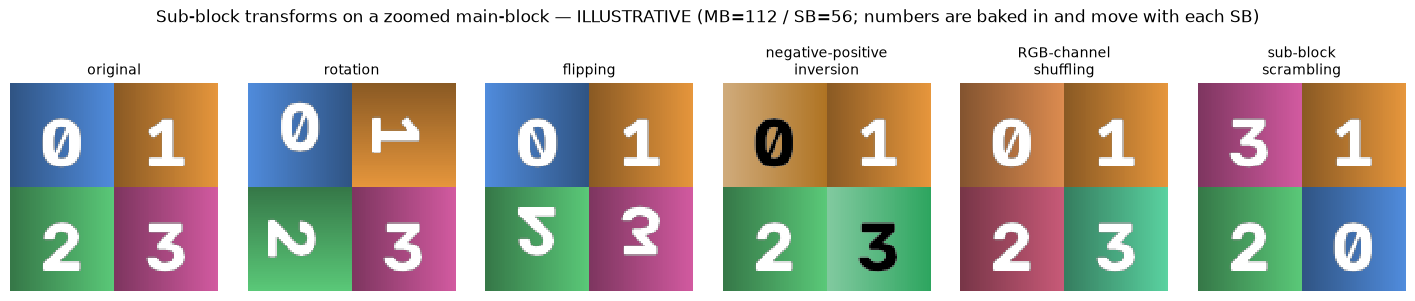

In [4]:
import cv2   # only used here, to draw numbers into the demo block

MB_DEMO = 112          # zoomed main-block size (illustrative, not the real 16)
SB_DEMO = 56           # sub-block size -> 2x2 SBs (illustrative, not the real 8)

PALETTE = [(80, 140, 220), (230, 150, 60), (90, 200, 120), (210, 90, 160),
           (180, 180, 70), (120, 120, 220), (70, 200, 200), (220, 110, 110)]


def _numbered_sub_block(index, sb_size):
    """One colored sub-block with its index painted into the pixels."""
    color = np.array(PALETTE[index % len(PALETTE)], np.uint8)
    # light left-to-right shading, so rotation/flip is visible too
    xx = np.mgrid[0:sb_size, 0:sb_size][1]
    sb = (color * (0.6 + 0.4 * xx / (sb_size - 1))[..., None]).astype(np.uint8)

    text, scale, thick = str(index), sb_size / 45.0, max(2, sb_size // 22)
    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, scale, thick)
    org = ((sb_size - tw) // 2, (sb_size + th) // 2)
    for color_bgr, t in [((0, 0, 0), thick + 2),        # dark outline
                         ((255, 255, 255), thick)]:     # white glyph on top
        cv2.putText(sb, text, org, cv2.FONT_HERSHEY_SIMPLEX, scale,
                    color_bgr, t, cv2.LINE_AA)
    return sb


def make_demo_main_block(mb_size=MB_DEMO, sb_size=SB_DEMO):
    """Build a single, zoomed-in main-block (MB) whose sub-blocks (SB) are
    colored AND numbered, with the number drawn into the pixels. Because the
    digit is part of the image, every transform moves it along with its SB --
    so you can read off where each sub-block went, how it was rotated, or
    whether only its color changed. (Teaching aid only; not MB=16 / SB=8.)"""
    mb = np.zeros((mb_size, mb_size, 3), np.uint8)
    n = mb_size // sb_size               # sub-blocks per side
    for by in range(n):
        for bx in range(n):
            mb[by*sb_size:(by+1)*sb_size, bx*sb_size:(bx+1)*sb_size] = \
                _numbered_sub_block(by * n + bx, sb_size)
    return mb


demo_mb = make_demo_main_block()

panels = [("original", demo_mb)]
panels += [(OP_LABELS[op], encrypt_single_op(demo_mb, op, sub_block_size=SB_DEMO))
           for op in SUB_BLOCK_OPS]

show_panels(panels,
            "Sub-block transforms on a zoomed main-block — ILLUSTRATIVE "
            "(MB=112 / SB=56; numbers are baked in and move with each SB)",
            width=2.4, height=2.8, caption_size=10, interpolation="nearest")

## Step 2 — Shuffling the blocks around

Everything so far scrambled pixels *inside* each block. This second level does
something simpler: it keeps each block intact but moves it to a **new position**
in the frame, like shuffling puzzle pieces.

Notice that no pixels are added or changed — the exact same pixels are just
rearranged. (The title below confirms this: the set of pixel values is
identical before and after.)

*(Paper: main-block scrambling A.4.)*

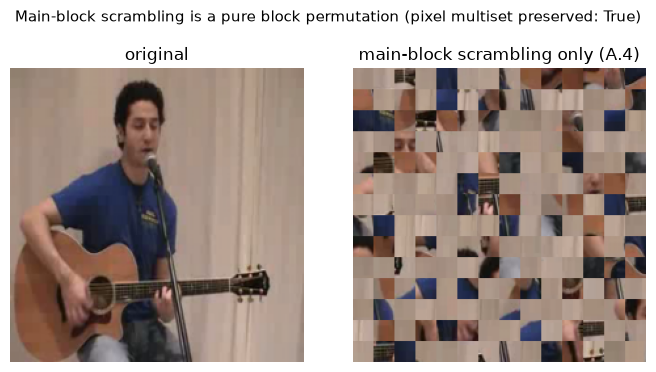

In [5]:
# only main-block scrambling active; all sub-block transforms off
only_mbs = encrypt_frame(
    frame, SEED, enabled={op: (op == "mbs") for op in ALL_ENCRYPTION_OPS})

# confirm it's a pure permutation of blocks: same pixels, different arrangement
same_pixels = np.array_equal(np.sort(frame.reshape(-1)),
                             np.sort(only_mbs.reshape(-1)))

show_panels([("original", frame),
             ("main-block scrambling only (A.4)", only_mbs)],
            f"Main-block scrambling is a pure block permutation "
            f"(pixel multiset preserved: {same_pixels})",
            width=3.5, height=3.6, title_size=11, y=1.02)

## Putting it all together

Now we switch the operations on one by one — rotation, then flipping, then color
inversion, then channel swap, then sub-block shuffle, and finally block
shuffle — and watch the picture dissolve into noise. The last panel is the fully
encrypted frame that would actually be sent out.

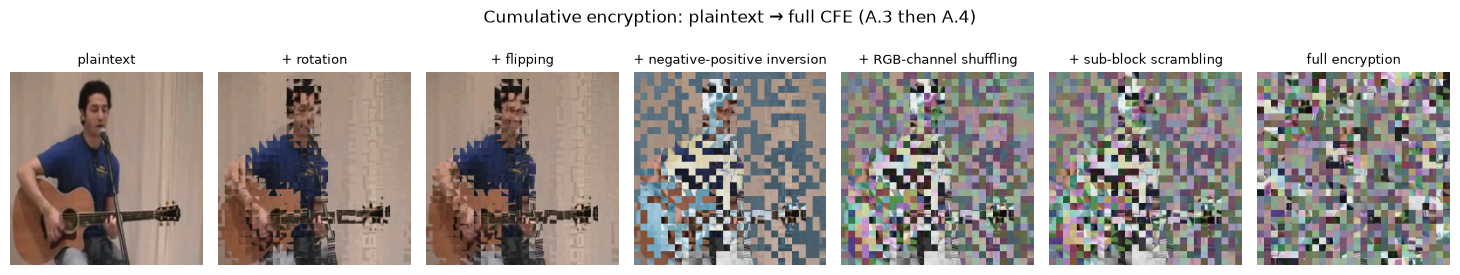

In [6]:
# switch ops on cumulatively, in paper order: the five A.3 ops, then A.4
panels = [("plaintext", frame)]
active = []
for op in ALL_ENCRYPTION_OPS:          # rot, flip, npt, cs, sbs, mbs
    active.append(op)
    caption = "+ " + OP_LABELS[op].replace("\n", " ")
    panels.append((caption, encrypt_frame(
        frame, SEED, enabled={o: (o in active) for o in ALL_ENCRYPTION_OPS})))

panels[-1] = ("full encryption", panels[-1][1])   # last panel = everything on

show_panels(panels, "Cumulative encryption: plaintext → full CFE (A.3 then A.4)",
            width=2.1, caption_size=9, y=1.05)

## Two key schemes: V1 vs V2

CFE-PPAR comes in two flavors, differing only in **how many keys** are used
within a frame:

- **V1** — every block is scrambled with the **same** key.
- **V2** — every block gets its **own** key.

Both hide the content just as well and both keep the model's accuracy. The
difference is about **security**: because V1 repeats one key everywhere, an
attacker has an easier time reassembling the picture (like solving a jigsaw);
V2's per-block keys make that much harder.

To the eye the two look equally scrambled below — but they're produced
differently, which the check at the end confirms.

*(Paper: Sec. 4.1 and the attack analysis in Sec. 4.5.)*

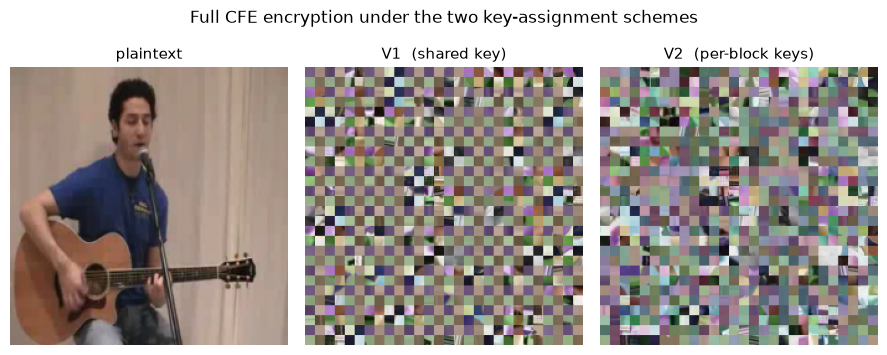

V1 and V2 produce different ciphertext: True


In [7]:
enc_v1 = encrypt_frame(frame, SEED, variant="V1")
enc_v2 = encrypt_frame(frame, SEED, variant="V2")

show_panels([("plaintext", frame),
             ("V1  (shared key)", enc_v1),
             ("V2  (per-block keys)", enc_v2)],
            "Full CFE encryption under the two key-assignment schemes",
            width=3.0, height=3.4, caption_size=11, y=1.03)

# same plaintext, same seed, different key assignment -> different ciphertext
print("V1 and V2 produce different ciphertext:",
      not np.array_equal(enc_v1, enc_v2))